In [ ]:
######### collect streams for the four focused cities separately in OSM
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

place_name = "Dresden, Germany"
# place_name = "Jablonec nad Nisou, Czech Republic"
# place_name = "Poznań, Poland"
# place_name = "Senica, Slovakia"

streams= ox.features_from_place(place_name,tags={"waterway":"stream"})

streams = streams.to_crs(epsg=3857)

print(streams.head())
print(f"Total streams found: {len(streams)}")

streams.to_file("dresden_stream.geojson", driver="GeoJSON")

city_boundary = ox.geocode_to_gdf(place_name)
city_boundary = city_boundary.to_crs(epsg=3857)

# visualise
fig, ax=plt.subplots(figsize=(12,8))
city_boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
streams.plot(ax=ax, color="dodgerblue",linewidth=1, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.5)
ax.set_title(place_name,fontsize=15)
ax.axis('off')
plt.show()


In [2]:
######### collect streams for the four focused cities separately
import osmnx as ox
import geopandas as gpd

# write a loop to save shp for each city boundary
for place_name in ["Dresden, Germany", "Jablonec nad Nisou, Czech Republic", "Poznań, Poland", "Senica, Slovakia"]:
     city_boundary = ox.geocode_to_gdf(place_name)
     city_boundary = city_boundary.to_crs(epsg=3857)
     city_boundary.to_file(f"{place_name}.shp")


/var/folders/58/86zdkmzd6y3d82s16dcq774cn10vxp/T/ipykernel_17550/2066476802.py:9: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  city_boundary.to_file(f"{place_name}.shp")
/Users/yehanwu/Github-projects/SpatialAnalysis/.venv/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'addresstype' to 'addresstyp'
  ogr_write(
/Users/yehanwu/Github-projects/SpatialAnalysis/.venv/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'display_name' to 'display_na'
  ogr_write(
/var/folders/58/86zdkmzd6y3d82s16dcq774cn10vxp/T/ipykernel_17550/2066476802.py:9: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  city_boundary.to_file(f"{place_name}.shp")
/Users/yehanwu/Github-projects/SpatialAnalysis/.venv/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'addre

<Axes: >

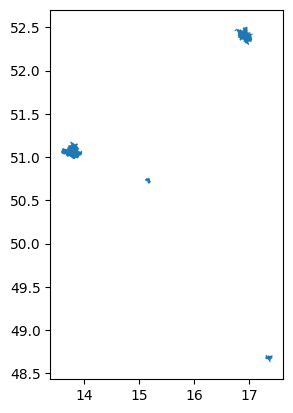

In [5]:
import pandas as pd
# combine the four above shp into one
city_boundaries = []
for place_name in ["Dresden, Germany", "Jablonec nad Nisou, Czech Republic", "Poznań, Poland", "Senica, Slovakia"]:
    city_boundary = gpd.read_file(f"{place_name}.shp")
    city_boundaries.append(city_boundary)
combined_city_boundaries = gpd.GeoDataFrame(pd.concat(city_boundaries, ignore_index=True))
combined_city_boundaries = combined_city_boundaries.to_crs(epsg=4326)
combined_city_boundaries.to_file("combined_city_boundaries.shp")

combined_city_boundaries.plot()
